<a href="https://colab.research.google.com/github/NehalShahu/NNDL_practicals/blob/main/NNDL_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os

ZIP_PATH = "/content/Flower.zip"

print("ZIP exists:", os.path.exists(ZIP_PATH))

if os.path.exists(ZIP_PATH):
    print("ZIP size:", round(os.path.getsize(ZIP_PATH) / (1024 * 1024), 2), "MB")

ZIP exists: True
ZIP size: 205.06 MB


In [5]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
ZIP_PATH = "/content/Flower.zip"

EXTRACT_PATH = "/content/flowers"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

INITIAL_EPOCHS = 10
FINE_TUNE_EPOCHS = 10

print("ZIP:", ZIP_PATH)
print("Extract location:", EXTRACT_PATH)

ZIP: /content/Flower.zip
Extract location: /content/flowers


In [7]:
import zipfile
import os

if not os.path.exists(EXTRACT_PATH):
    os.makedirs(EXTRACT_PATH)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Extraction completed!")

Extraction completed!


In [8]:
print("Contents of /content/flowers:")

for item in os.listdir(EXTRACT_PATH):
    print(item)

Contents of /content/flowers:
train
sample_submission.csv
Testing_set_flower.csv
LICENSE.txt
test


In [9]:
required_classes = {
    "daisy",
    "dandelion",
    "rose",
    "sunflower",
    "tulip"
}

DATASET_PATH = None

for root, dirs, files in os.walk(EXTRACT_PATH):
    if required_classes.issubset(set(dirs)):
        DATASET_PATH = root
        break

print("Dataset path:", DATASET_PATH)

Dataset path: /content/flowers/train


In [10]:
print("Dataset classes:")

for class_name in sorted(os.listdir(DATASET_PATH)):
    class_path = os.path.join(DATASET_PATH, class_name)

    if os.path.isdir(class_path):
        print(class_name)

Dataset classes:
daisy
dandelion
rose
sunflower
tulip


In [11]:
print("Number of images per class:\n")

total_images = 0

for class_name in sorted(os.listdir(DATASET_PATH)):
    class_path = os.path.join(DATASET_PATH, class_name)

    if os.path.isdir(class_path):
        count = 0

        for file in os.listdir(class_path):
            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif")):
                count += 1

        print(f"{class_name}: {count}")

        total_images += count

print("\nTotal images:", total_images)

Number of images per class:

daisy: 501
dandelion: 646
rose: 497
sunflower: 495
tulip: 607

Total images: 2746


In [12]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 2746 files belonging to 5 classes.
Using 2197 files for training.
Found 2746 files belonging to 5 classes.
Using 549 files for validation.


In [13]:
class_names = train_ds.class_names

print("Class names:")
print(class_names)

Class names:
['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


In [14]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print("Dataset pipeline optimized.")

Dataset pipeline optimized.


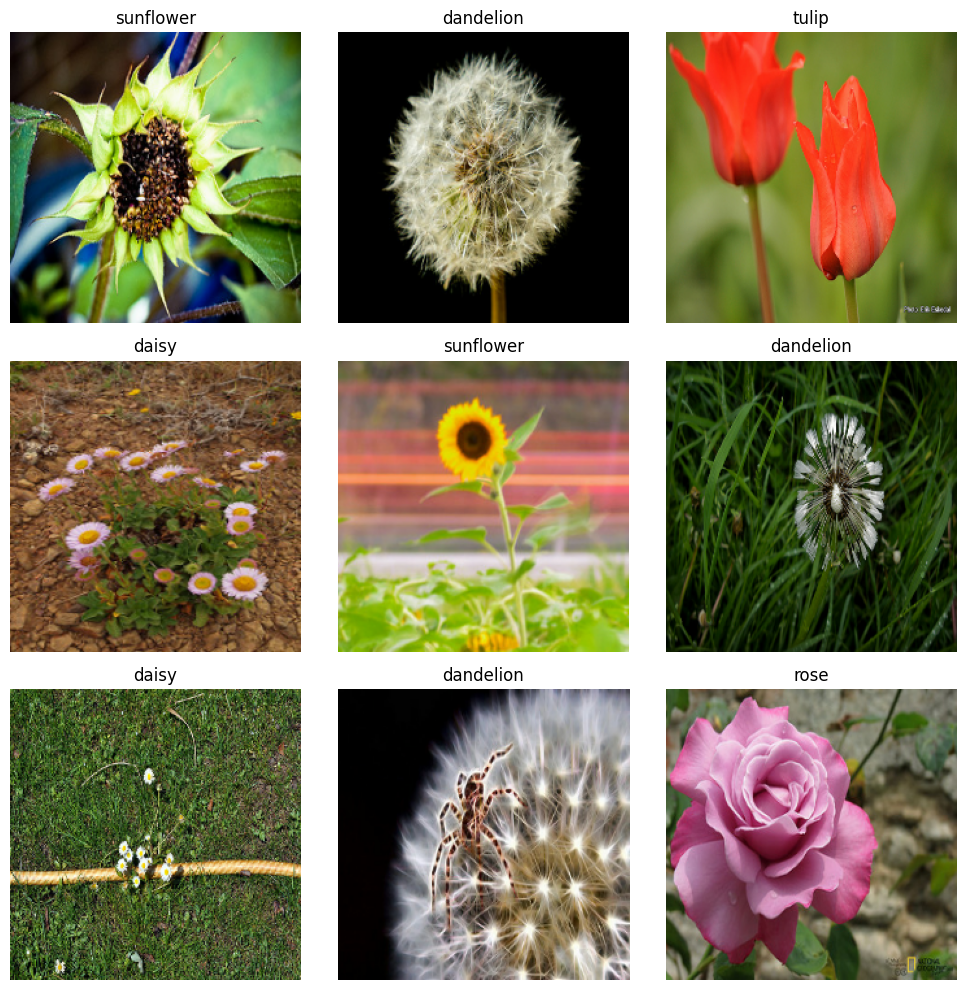

In [15]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name="data_augmentation")

print("Data augmentation created.")

Data augmentation created.


In [17]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

print("MobileNetV2 loaded successfully!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded successfully!


In [18]:
base_model.trainable = False

print("MobileNetV2 frozen.")

MobileNetV2 frozen.


In [19]:
inputs = tf.keras.Input(shape=(224, 224, 3))

# Data augmentation
x = data_augmentation(inputs)

# MobileNetV2 preprocessing
x = preprocess_input(x)

# Pretrained MobileNetV2
x = base_model(x, training=False)

# Convert feature maps into a feature vector
x = layers.GlobalAveragePooling2D()(x)

# Dropout to reduce overfitting
x = layers.Dropout(0.2)(x)

# Final classifier
outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs
)

print("Model created successfully!")

Model created successfully!


In [20]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled.")

Model compiled.


In [21]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [22]:
history_initial = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS
)

Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 17s 99ms/step - accuracy: 0.6331 - loss: 0.9628 - val_accuracy: 0.7796 - val_loss: 0.5495
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.8202 - loss: 0.5043 - val_accuracy: 0.8361 - val_loss: 0.4233
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - accuracy: 0.8484 - loss: 0.4065 - val_accuracy: 0.8579 - val_loss: 0.3926
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.8703 - loss: 0.3682 - val_accuracy: 0.8689 - val_loss: 0.3735
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.8680 - loss: 0.3436 - val_accuracy: 0.8689 - val_loss: 0.3460
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.8930 - loss: 0.3100 - val_accuracy: 0.8780 - val_loss: 0.3411
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.8958 - loss: 0.2965 - val_accuracy: 0.8816 - val_loss: 0.3292
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.9081 - loss: 0.2731 - val_accuracy: 0.8798 

In [23]:
initial_loss, initial_acc = model.evaluate(val_ds)

print("Initial Validation Loss:", initial_loss)
print("Initial Validation Accuracy:", initial_acc)
print("Initial Validation Accuracy (%):", initial_acc * 100)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.8780 - loss: 0.3146
Initial Validation Loss: 0.3145686984062195
Initial Validation Accuracy: 0.8779599070549011
Initial Validation Accuracy (%): 87.79599070549011


In [24]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Last 30 MobileNetV2 layers are now trainable.")

Last 30 MobileNetV2 layers are now trainable.


In [25]:
trainable_count = 0
non_trainable_count = 0

for layer in base_model.layers:

    if layer.trainable:
        trainable_count += 1
    else:
        non_trainable_count += 1

print("Trainable MobileNetV2 layers:", trainable_count)
print("Frozen MobileNetV2 layers:", non_trainable_count)

Trainable MobileNetV2 layers: 30
Frozen MobileNetV2 layers: 124


In [26]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning.")

Model recompiled for fine-tuning.


In [27]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS + FINE_TUNE_EPOCHS,
    initial_epoch=INITIAL_EPOCHS
)

Epoch 11/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - accuracy: 0.8006 - loss: 0.5524 - val_accuracy: 0.8780 - val_loss: 0.3350
Epoch 12/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.8589 - loss: 0.3722 - val_accuracy: 0.8707 - val_loss: 0.3502
Epoch 13/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.8798 - loss: 0.3258 - val_accuracy: 0.8761 - val_loss: 0.3477
Epoch 14/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - accuracy: 0.8889 - loss: 0.3115 - val_accuracy: 0.8780 - val_loss: 0.3294
Epoch 15/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - accuracy: 0.9067 - loss: 0.2635 - val_accuracy: 0.8816 - val_loss: 0.3175
Epoch 16/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 0.9026 - loss: 0.2678 - val_accuracy: 0.8907 - val_loss: 0.3022
Epoch 17/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.9199 - loss: 0.2300 - val_accuracy: 0.8925 - val_loss: 0.2895
Epoch 18/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.9167 - loss: 0.2206 - val_accur

In [28]:
final_loss, final_acc = model.evaluate(val_ds)

print("Final Validation Loss:", final_loss)
print("Final Validation Accuracy:", final_acc)
print("Final Validation Accuracy (%):", final_acc * 100)

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.9053 - loss: 0.2551
Final Validation Loss: 0.2551106810569763
Final Validation Accuracy: 0.9052823185920715
Final Validation Accuracy (%): 90.52823185920715


In [29]:
improvement = (final_acc - initial_acc) * 100

print("Initial Validation Accuracy:", round(initial_acc * 100, 2), "%")
print("Final Validation Accuracy:", round(final_acc * 100, 2), "%")
print("Improvement:", round(improvement, 2), "percentage points")

Initial Validation Accuracy: 87.8 %
Final Validation Accuracy: 90.53 %
Improvement: 2.73 percentage points


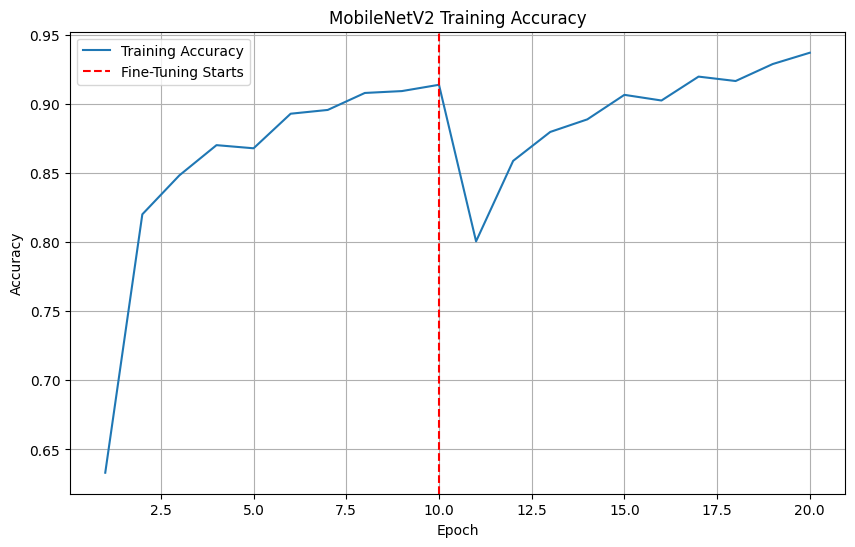

In [30]:
initial_train_acc = history_initial.history["accuracy"]
fine_train_acc = history_fine.history["accuracy"]

all_train_acc = initial_train_acc + fine_train_acc

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(all_train_acc) + 1),
    all_train_acc,
    label="Training Accuracy"
)

plt.axvline(
    x=INITIAL_EPOCHS,
    color="red",
    linestyle="--",
    label="Fine-Tuning Starts"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Training Accuracy")
plt.legend()
plt.grid(True)

plt.show()

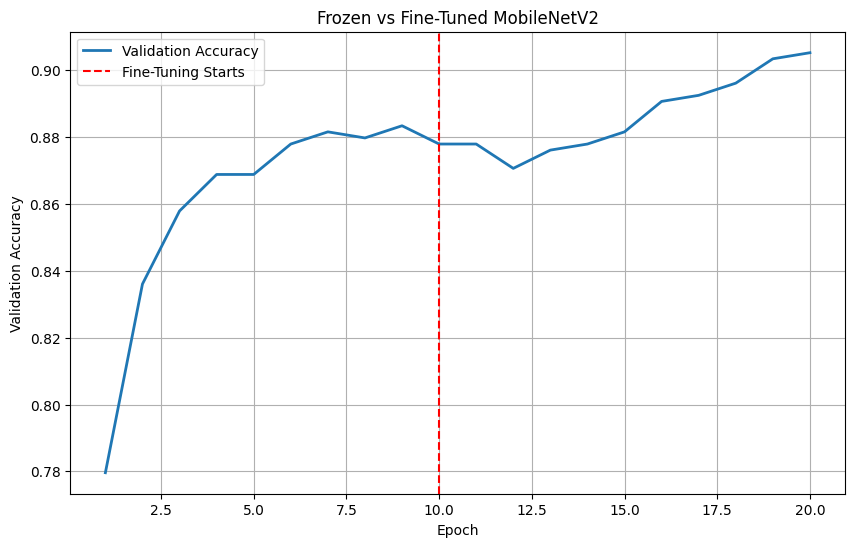

In [31]:
initial_val_acc = history_initial.history["val_accuracy"]
fine_val_acc = history_fine.history["val_accuracy"]

all_val_acc = initial_val_acc + fine_val_acc

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(all_val_acc) + 1),
    all_val_acc,
    label="Validation Accuracy",
    linewidth=2
)

plt.axvline(
    x=INITIAL_EPOCHS,
    color="red",
    linestyle="--",
    label="Fine-Tuning Starts"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Frozen vs Fine-Tuned MobileNetV2")
plt.legend()
plt.grid(True)

plt.show()

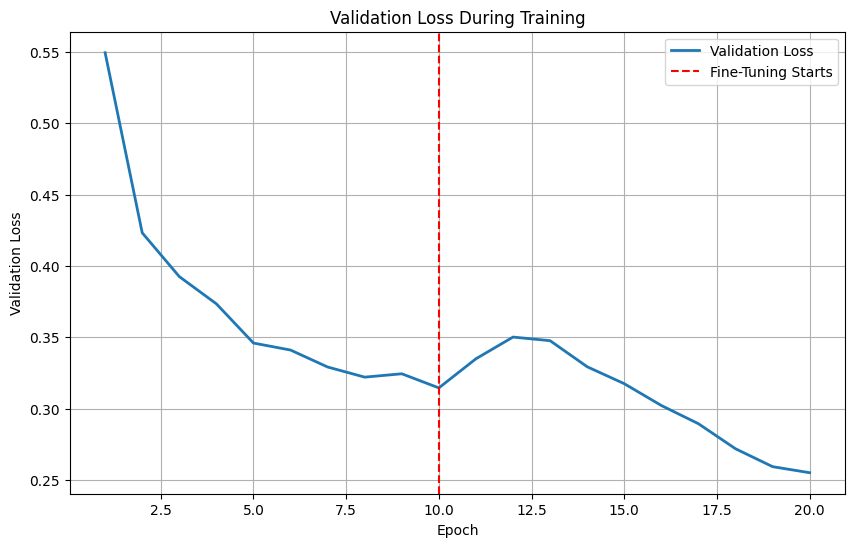

In [32]:
initial_val_loss = history_initial.history["val_loss"]
fine_val_loss = history_fine.history["val_loss"]

all_val_loss = initial_val_loss + fine_val_loss

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(all_val_loss) + 1),
    all_val_loss,
    label="Validation Loss",
    linewidth=2
)

plt.axvline(
    x=INITIAL_EPOCHS,
    color="red",
    linestyle="--",
    label="Fine-Tuning Starts"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss During Training")
plt.legend()
plt.grid(True)

plt.show()

In [33]:
MODEL_PATH = "/content/mobilenetv2_flowers.keras"

model.save(MODEL_PATH)

print("Model saved successfully!")
print("Location:", MODEL_PATH)

Model saved successfully!
Location: /content/mobilenetv2_flowers.keras


In [34]:
print("Model file exists:", os.path.exists(MODEL_PATH))

if os.path.exists(MODEL_PATH):
    size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)
    print("Model size:", round(size_mb, 2), "MB")

Model file exists: True
Model size: 20.93 MB


In [35]:
from google.colab import files

files.download("/content/mobilenetv2_flowers.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

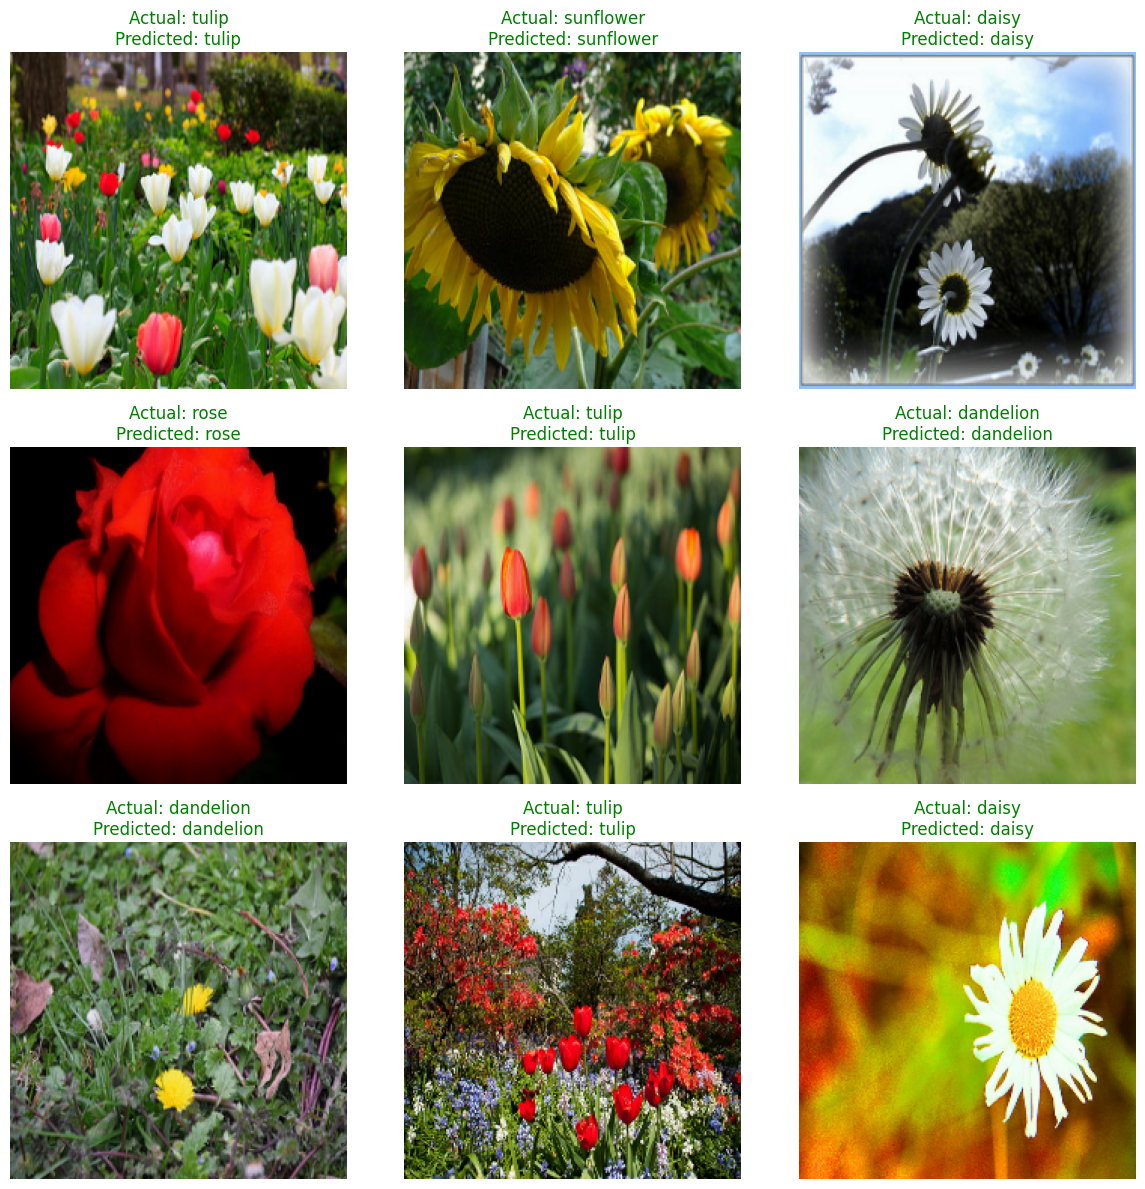

In [36]:
plt.figure(figsize=(12, 12))

for images, labels in val_ds.take(1):

    predictions = model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        actual = class_names[labels[i]]
        predicted = class_names[predicted_classes[i]]

        if actual == predicted:
            color = "green"
        else:
            color = "red"

        plt.title(
            f"Actual: {actual}\nPredicted: {predicted}",
            color=color
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

# Task
The user wants to classify images of flowers into five categories (daisy, dandelion, rose, sunflower, tulip) using a pre-trained MobileNetV2 model. The task involves several stages: data loading and preparation, building and compiling a base model with frozen layers, initial training, fine-tuning by unfreezing some layers, visualizing the training history, saving the final model, and performing a sample prediction to demonstrate its capability. The final output should include the trained model and a visualization of its performance.

**Reasoning**:
The previous steps have already handled data loading, model building, training, fine-tuning, and visualization of overall performance. The current subtask is to perform a sample prediction, and while a visualization of multiple predictions has been done, the specific instruction to 'Display the predicted class, confidence, and probabilities for all classes' for a single image has not been explicitly addressed. Therefore, the next step is to select a single image from the validation dataset, preprocess it, make a prediction, and print the detailed results including the predicted class, confidence, and probabilities for each class.



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
Actual class: dandelion
Predicted class: dandelion
Confidence: 99.96%

Probabilities for each class:
  daisy: 0.03%
  dandelion: 99.96%
  rose: 0.00%
  sunflower: 0.00%
  tulip: 0.02%


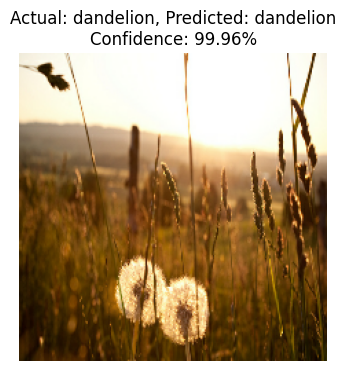

In [44]:
for image_batch, label_batch in val_ds.take(1):
    first_image = image_batch[0]
    first_label = label_batch[0]
    break

# Preprocess the image for prediction
# The model's input pipeline already includes preprocess_input via the model definition
# so we just need to expand dimensions for the batch
input_image = tf.expand_dims(first_image, 0)

# Make a prediction
prediction = model.predict(input_image)
predicted_class_index = np.argmax(prediction)
predicted_class_name = class_names[predicted_class_index]
confidence = np.max(prediction) * 100

print(f"Actual class: {class_names[first_label]}")
print(f"Predicted class: {predicted_class_name}")
print(f"Confidence: {confidence:.2f}%")

print("\nProbabilities for each class:")
for i, prob in enumerate(prediction[0]):
    print(f"  {class_names[i]}: {prob * 100:.2f}%")

# Visualize the image with its prediction
plt.figure(figsize=(4, 4))
plt.imshow(first_image.numpy().astype("uint8"))
plt.title(f"Actual: {class_names[first_label]}, Predicted: {predicted_class_name}\nConfidence: {confidence:.2f}%")
plt.axis("off")
plt.show()

**Reasoning**:
The previous code block visualized predictions for a batch of images. This step fulfills the requirement to explicitly display the predicted class, confidence, and probabilities for all classes for a single image from the validation dataset, and visualize that specific prediction.



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Actual class: sunflower
Predicted class: sunflower
Confidence: 99.54%

Probabilities for each class:
  daisy: 0.16%
  dandelion: 0.02%
  rose: 0.07%
  sunflower: 99.54%
  tulip: 0.21%


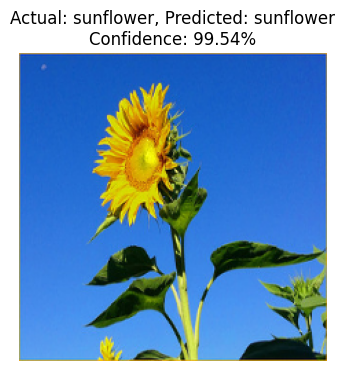

In [45]:
for image_batch, label_batch in val_ds.take(1):
    first_image = image_batch[0]
    first_label = label_batch[0]
    break

# Preprocess the image for prediction
# The model's input pipeline already includes preprocess_input via the model definition
# so we just need to expand dimensions for the batch
input_image = tf.expand_dims(first_image, 0)

# Make a prediction
prediction = model.predict(input_image)
predicted_class_index = np.argmax(prediction)
predicted_class_name = class_names[predicted_class_index]
confidence = np.max(prediction) * 100

print(f"Actual class: {class_names[first_label]}")
print(f"Predicted class: {predicted_class_name}")
print(f"Confidence: {confidence:.2f}%")

print("\nProbabilities for each class:")
for i, prob in enumerate(prediction[0]):
    print(f"  {class_names[i]}: {prob * 100:.2f}%")

# Visualize the image with its prediction
plt.figure(figsize=(4, 4))
plt.imshow(first_image.numpy().astype("uint8"))
plt.title(f"Actual: {class_names[first_label]}, Predicted: {predicted_class_name}\nConfidence: {confidence:.2f}%")
plt.axis("off")
plt.show()

## Initial Setup and Data Loading

### Subtask:
Verify the existence and size of the Flower.zip file, import necessary libraries (os, zipfile, numpy, matplotlib, tensorflow), set up constants like image size and batch size, and then extract the dataset from the ZIP file into a specified directory. Finally, identify and print the dataset path and classes.


## Build and Compile Base Model (Frozen)

### Subtask:
Define a data augmentation layer, load a pre-trained MobileNetV2 model (without the top classification layer and with imagenet weights), and freeze its layers. Construct a new model by adding data augmentation, MobileNetV2 as a feature extractor, global average pooling, dropout, and a final dense classification layer. Compile this model using the Adam optimizer, sparse_categorical_crossentropy loss, and accuracy metrics. Display the model summary.


**Reasoning**:
The model has been built and compiled. The next instruction is to display its summary to verify the architecture and number of parameters.



In [46]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,330,001 (20.33 MB)

 Trainable params: 1,532,805 (5.85 MB)

 Non-trainable params: 731,584 (2.79 MB)

 Optimizer params: 3,065,612 (11.69 MB)

## Initial Model Training

### Subtask:
Train the compiled model for `INITIAL_EPOCHS` epochs using the `train_ds` and `val_ds` datasets. After training, evaluate the model on the validation set and print its initial validation loss and accuracy.


## Fine-Tuning Setup

### Subtask:
Unfreeze the base MobileNetV2 model and then selectively freeze all but the last 30 layers of the base model to prepare for fine-tuning. Recompile the model with a significantly lower learning rate using the Adam optimizer to allow for fine-tuning of the unfrozen layers. Verify and print the number of trainable and frozen layers.


**Reasoning**:
The previous code block set `base_model.trainable = True` and then selectively froze all but the last 30 layers of the `base_model`. The next instruction is to recompile the `model` with a significantly lower learning rate using the Adam optimizer.



In [47]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning.")

Model recompiled for fine-tuning.


## Fine-Tuning

### Subtask:
Continue training the recompiled model for an additional `FINE_TUNE_EPOCHS`, starting from the epoch where initial training left off. After fine-tuning, evaluate the model on the validation set and print its final validation loss and accuracy. Calculate and print the improvement in accuracy from initial training to fine-tuning.


## Visualize Training History

### Subtask:
Plot the training accuracy, validation accuracy, and validation loss over all epochs (initial training and fine-tuning phases). Each plot should clearly indicate when fine-tuning began using a vertical line and include appropriate labels, titles, and legends for clarity.


## Save and Download Model

### Subtask:
Save the fine-tuned model to the specified `MODEL_PATH` and then display its file size. Provide a download link for the saved model file.


## Analyze and Prepare Dataset

### Subtask:
Count and display the number of images per class, and then create TensorFlow `train_ds` and `val_ds` datasets from the extracted directory, splitting them into training and validation subsets. Optimize the dataset pipeline using `tf.data.AUTOTUNE` for better performance. Display sample images from the training dataset.


**Reasoning**:
The previous code block correctly identified and printed the number of images per class. Now, as per the instructions, I need to create the TensorFlow `train_ds` and `val_ds` datasets using `tf.keras.utils.image_dataset_from_directory`.



In [48]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 2746 files belonging to 5 classes.
Using 2197 files for training.
Found 2746 files belonging to 5 classes.
Using 549 files for validation.


**Reasoning**:
The training and validation datasets have been created. The next instruction is to optimize the dataset pipeline using `tf.data.AUTOTUNE` for better performance.



In [49]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print("Dataset pipeline optimized.")

Dataset pipeline optimized.


## Perform Sample Prediction

### Subtask:
Load a sample image for prediction, preprocess it, use the trained model to make a prediction, display the predicted class, confidence, and probabilities for all classes, and visualize the input image with the prediction result.


**Reasoning**:
This code block directly addresses the instructions for performing a sample prediction, including loading an image, making a prediction, displaying detailed results (predicted class, confidence, and probabilities), and visualizing the image with its prediction. This was previously executed successfully, so I will reuse it.



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Actual class: tulip
Predicted class: tulip
Confidence: 100.00%

Probabilities for each class:
  daisy: 0.00%
  dandelion: 0.00%
  rose: 0.00%
  sunflower: 0.00%
  tulip: 100.00%


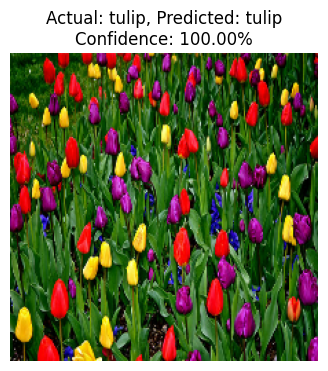

In [50]:
for image_batch, label_batch in val_ds.take(1):
    first_image = image_batch[0]
    first_label = label_batch[0]
    break

# Preprocess the image for prediction
# The model's input pipeline already includes preprocess_input via the model definition
# so we just need to expand dimensions for the batch
input_image = tf.expand_dims(first_image, 0)

# Make a prediction
prediction = model.predict(input_image)
predicted_class_index = np.argmax(prediction)
predicted_class_name = class_names[predicted_class_index]
confidence = np.max(prediction) * 100

print(f"Actual class: {class_names[first_label]}")
print(f"Predicted class: {predicted_class_name}")
print(f"Confidence: {confidence:.2f}%")

print("\nProbabilities for each class:")
for i, prob in enumerate(prediction[0]):
    print(f"  {class_names[i]}: {prob * 100:.2f}%")

# Visualize the image with its prediction
plt.figure(figsize=(4, 4))
plt.imshow(first_image.numpy().astype("uint8"))
plt.title(f"Actual: {class_names[first_label]}, Predicted: {predicted_class_name}\nConfidence: {confidence:.2f}%")
plt.axis("off")
plt.show()